# [The Lottery Ticket Hypothesis](https://arxiv.org/pdf/1803.03635)

## Introduction

**Pruning**: Removing redundant weights to improve efficiency with minimal performance loss.

Previous pruning techniques **required a fully trained model** before pruning, so most **efficiency gains were realized during inference** rather than training. 

Can we **prune without having full training cost?**


**Current gap**: Training a pruned network from scratch typically results in worse performance than retraining / fine-tuning, giving no clear indication that pruning prior to training is feasible.

**Improvement**: Proposes hypothesis suggesting that networks contain subnetworks which, if reset to their original initialization, can be trained from scratch to match full-network performance in similar number of training iterations.

## Result

Algorithm consistently finds subnetworks that achieve comparable performance to original network, despite being less than **10%-20%** of the original size.

At sizes **greater than 10%-20%** of the original size, subnetworks **achieve higher test accuracy** than original network.

## Approach

1. Randomly initialize a neural network,  $f(x; θ_0)$ (where $θ_0 ∼ D_θ$).
2. Train the network for $j$ iterations
3. Prune $p\%$ of the parameters in $θ_j$, creating a mask $m$.
4. Reset the remaining parameters to their values in $θ_0$, creating the winning ticket $f(x; θ_0 \odot m)$


## Application

### 0. Data

In [302]:
import torch
import torchvision
import torchvision.transforms as transforms

In [303]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [304]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


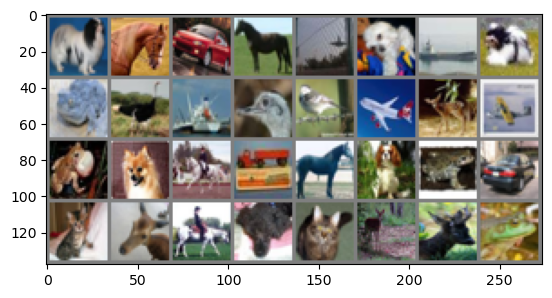

dog   horse car   horse plane dog   ship  dog   frog  bird  ship  bird  bird  plane deer  plane frog  dog   horse truck horse dog   frog  car   cat   deer  horse dog   cat   deer  deer  frog 


In [305]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### 1. Randomly Initialize Model

In [306]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)
initial_state = copy.deepcopy(net.state_dict())

### 2. Train Model

In [307]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [308]:
from tqdm import tqdm

def train(net, epochs=12, mask_dict=None):
    net.train()

    for epoch in range(epochs):
        running_loss = 0.0

        loop = tqdm(enumerate(trainloader), total=len(trainloader), leave=True)

        for i, data in loop:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            # --- Mask gradients (prevent updates to pruned weights) ---
            if mask_dict is not None:
                for name, param in net.named_parameters():
                    if "weight" in name and name in mask_dict:
                        if param.grad is not None:
                            param.grad.mul_(mask_dict[name])

            optimizer.step()

            # --- Re-apply mask (force weights to stay zero) ---
            if mask_dict is not None:
                with torch.no_grad():
                    for name, param in net.named_parameters():
                        if "weight" in name and name in mask_dict:
                            param.mul_(mask_dict[name])

            running_loss += loss.item()

    print('Finished Training')

In [309]:
train(net)

100%|█████████████████████████████████████████████████| 1563/1563 [00:08<00:00, 188.58it/s]

Finished Training


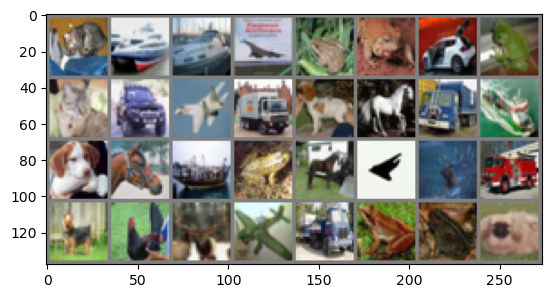

GroundTruth:  cat   ship  ship  plane


In [310]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [311]:
def test_acc(model):
    """
    Compute per-class accuracy and overall accuracy.
    """
    model.eval()
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            # update per-class metrics
            for label, prediction in zip(labels, predictions):
                label_name = classes[label]
                if label == prediction:
                    correct_pred[label_name] += 1
                    total_correct += 1
                total_pred[label_name] += 1
                total_samples += 1

    # compute accuracy per class
    acc_per_class = {}
    for classname in classes:
        acc = 100 * float(correct_pred[classname]) / total_pred[classname] if total_pred[classname] > 0 else 0
        acc_per_class[classname] = acc

    # compute overall accuracy
    overall_acc = 100 * total_correct / total_samples if total_samples > 0 else 0

    return acc_per_class, overall_acc
    
def test_f1(model):
    """
    Compute per-class F1 score and overall (macro) F1.
    """
    model.eval()
    tp = {classname: 0 for classname in classes}
    fp = {classname: 0 for classname in classes}
    fn = {classname: 0 for classname in classes}

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            for label, prediction in zip(labels, predictions):
                label_name = classes[label]
                pred_name = classes[prediction]

                if label == prediction:
                    tp[label_name] += 1
                else:
                    fp[pred_name] += 1
                    fn[label_name] += 1

    # compute F1 per class
    f1_per_class = {}
    for classname in classes:
        precision = tp[classname] / (tp[classname] + fp[classname]) if (tp[classname] + fp[classname]) > 0 else 0
        recall = tp[classname] / (tp[classname] + fn[classname]) if (tp[classname] + fn[classname]) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_per_class[classname] = f1

    # overall F1 (macro)
    overall_f1 = sum(f1_per_class.values()) / len(classes) if len(classes) > 0 else 0

    return f1_per_class, overall_f1

# Compute per-class accuracy
acc_per_class, overall_acc = test_acc(net)

# Compute per-class F1 score
f1_per_class, overall_f1 = test_f1(net)

# Print both together
print("\nCombined metrics per class:")
for classname in classes:
    print(f'Class: {classname:5s} | Accuracy: {acc_per_class[classname]:6.2f}% | F1: {f1_per_class[classname]:.3f}')
print(f'\nOverall Accuracy: {overall_acc:6.2f}% | Overall F1: {overall_f1:.3f}')


Combined metrics per class:
Class: plane | Accuracy:  58.60% | F1: 0.653
Class: car   | Accuracy:  80.20% | F1: 0.727
Class: bird  | Accuracy:  49.70% | F1: 0.500
Class: cat   | Accuracy:  45.20% | F1: 0.435
Class: deer  | Accuracy:  58.60% | F1: 0.522
Class: dog   | Accuracy:  44.40% | F1: 0.493
Class: frog  | Accuracy:  74.70% | F1: 0.680
Class: horse | Accuracy:  62.50% | F1: 0.676
Class: ship  | Accuracy:  75.80% | F1: 0.753
Class: truck | Accuracy:  59.40% | F1: 0.652

Overall Accuracy:  60.91% | Overall F1: 0.609


### 3. Prune

In [312]:
import copy
baseline_state = copy.deepcopy(net.state_dict())
baseline_acc = overall_acc
baseline_f1 = overall_f1

In [313]:
def update_prune_mask(model, mask, prune_fraction=0.10):
    """
    Computes global magnitude threshold among *unpruned* weights,
    updates the mask cumulatively, and returns the new mask.
    """
    # --- Compute global magnitude threshold (among unpruned weights only) ---
    all_weights = torch.cat([
        (param.detach().abs() * mask[name]).flatten()
        for name, param in model.named_parameters()
        if "weight" in name
    ])

    unpruned = all_weights[all_weights != 0]
    if unpruned.numel() == 0:
        return mask  # nothing left to prune

    k = int(prune_fraction * unpruned.numel())
    if k <= 0:
        return mask

    threshold = torch.topk(unpruned, k, largest=False).values.max()

    # --- Update mask cumulatively ---
    new_mask = {}
    for name, param in model.named_parameters():
        if "weight" in name:
            weight_new_mask = ((param.detach().abs() > threshold).float()) * mask[name]
            new_mask[name] = weight_new_mask
        else:
            continue

    return new_mask

def count_remaining_params(model):
    remaining = 0
    total = 0
    for name, param in model.named_parameters():
        if "weight" in name:
            total += param.numel()
            remaining += (param.detach() != 0).sum().item()
    return remaining, total

In [314]:
# --- Reload baseline for magnitude pruning ---
net.load_state_dict(baseline_state)

# --- Initialize pruned-mask dictionary to all ones ---
mask = {name: torch.ones_like(param) for name, param in net.named_parameters() if "weight" in name}

# --- Initialize stats to save ---
acc_list = [baseline_acc]
f1_list = [baseline_f1]
remaining_params = sum(mask.sum().item() for mask in mask.values())
remaining_params_list = [remaining_params]

# --- Iterative pruning loop ---
PRUNING_STEPS = 5
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

for prune_iter in range(PRUNING_STEPS):
    print(f"\n--- Magnitude Pruning Iteration {prune_iter+1}/{PRUNING_STEPS} ---")

    mask = update_prune_mask(net, mask, prune_fraction=0.10)

    # --- Fine-tune the pruned model ---
    train(net, epochs=2, mask_dict=mask)

    # --- Evaluate ---
    acc_per_class, acc = test_acc(net)
    f1_per_class, f1 = test_f1(net)

    # --- Compute and save sparsity stats ---
    remaining_params, total_params = count_remaining_params(net)
    acc_list.append(acc)
    f1_list.append(f1)
    remaining_params_list.append(remaining_params)
    print(f"remaining_params={remaining_params}/{total_params} ({remaining_params/total_params*100:.2f}%), acc={acc:.2f}%, f1={f1:.3f}")


--- Magnitude Pruning Iteration 1/5 ---


100%|█████████████████████████████████████████████████| 1563/1563 [00:08<00:00, 178.29it/s]


Finished Training
remaining_params=55593/61770 (90.00%), acc=62.17%, f1=0.618

--- Magnitude Pruning Iteration 2/5 ---


100%|█████████████████████████████████████████████████| 1563/1563 [00:08<00:00, 175.93it/s]


Finished Training
remaining_params=50034/61770 (81.00%), acc=62.10%, f1=0.621

--- Magnitude Pruning Iteration 3/5 ---


...

Finished Training
remaining_params=45031/61770 (72.90%), acc=63.43%, f1=0.631

--- Magnitude Pruning Iteration 4/5 ---


100%|█████████████████████████████████████████████████| 1563/1563 [00:08<00:00, 177.39it/s]


Finished Training
remaining_params=40528/61770 (65.61%), acc=63.89%, f1=0.635

--- Magnitude Pruning Iteration 5/5 ---


100%|█████████████████████████████████████████████████| 1563/1563 [00:08<00:00, 180.80it/s]


Finished Training
remaining_params=36476/61770 (59.05%), acc=64.24%, f1=0.640


### 4. Reset parameters

In [339]:
# total remaining parameters
total_remaining = sum(mask_tensor.sum().item() for mask_tensor in mask.values())

# total original parameters
total_params = sum(mask_tensor.numel() for mask_tensor in mask.values())

# compute percentage
percent_remaining = 100 * total_remaining / total_params

print(f"Remaining parameters: {total_remaining}/{total_params} ({percent_remaining:.2f}%)")

Remaining parameters: 36476.0/61770 (59.05%)


### Re-initialize and Train

In [340]:
net = Net().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [341]:
train(net, epochs=12, mask_dict=mask)

100%|█████████████████████████████████████████████████| 1563/1563 [00:11<00:00, 132.72it/s]

Finished Training


In [342]:
# Compute per-class accuracy
acc_per_class, overall_acc = test_acc(net)

# Compute per-class F1 score
f1_per_class, overall_f1 = test_f1(net)

# Print both together
print("\nCombined metrics per class:")
for classname in classes:
    print(f'Class: {classname:5s} | Accuracy: {acc_per_class[classname]:6.2f}% | F1: {f1_per_class[classname]:.3f}')
print(f'\nOverall Accuracy: {overall_acc:6.2f}% | Overall F1: {overall_f1:.3f}')


Combined metrics per class:
Class: plane | Accuracy:  49.40% | F1: 0.576
Class: car   | Accuracy:  46.00% | F1: 0.603
Class: bird  | Accuracy:  55.00% | F1: 0.482
Class: cat   | Accuracy:  51.30% | F1: 0.425
Class: deer  | Accuracy:  35.30% | F1: 0.432
Class: dog   | Accuracy:  35.70% | F1: 0.423
Class: frog  | Accuracy:  60.80% | F1: 0.628
Class: horse | Accuracy:  72.50% | F1: 0.630
Class: ship  | Accuracy:  81.00% | F1: 0.667
Class: truck | Accuracy:  66.00% | F1: 0.636

Overall Accuracy:  55.30% | Overall F1: 0.550


### Reset parameters and Train

In [343]:
net = Net().to(device)
net.load_state_dict(initial_state)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [344]:
train(net, epochs=12, mask_dict=mask) # Winning ticket: (net, mask)

100%|█████████████████████████████████████████████████| 1563/1563 [00:11<00:00, 132.83it/s]

Finished Training


In [345]:
# Compute per-class accuracy
acc_per_class, overall_acc = test_acc(net)

# Compute per-class F1 score
f1_per_class, overall_f1 = test_f1(net)

# Print both together
print("\nCombined metrics per class:")
for classname in classes:
    print(f'Class: {classname:5s} | Accuracy: {acc_per_class[classname]:6.2f}% | F1: {f1_per_class[classname]:.3f}')
print(f'\nOverall Accuracy: {overall_acc:6.2f}% | Overall F1: {overall_f1:.3f}')


Combined metrics per class:
Class: plane | Accuracy:  66.20% | F1: 0.683
Class: car   | Accuracy:  78.80% | F1: 0.747
Class: bird  | Accuracy:  47.10% | F1: 0.512
Class: cat   | Accuracy:  39.80% | F1: 0.431
Class: deer  | Accuracy:  60.90% | F1: 0.572
Class: dog   | Accuracy:  55.30% | F1: 0.541
Class: frog  | Accuracy:  79.90% | F1: 0.711
Class: horse | Accuracy:  59.30% | F1: 0.683
Class: ship  | Accuracy:  72.10% | F1: 0.757
Class: truck | Accuracy:  73.90% | F1: 0.671

Overall Accuracy:  63.33% | Overall F1: 0.631
